# RQ01: Qual é o grau de sobreposição lexical e semântica de diretrizes em repositórios de código aberto que mantêm múltiplos arquivos de contexto para diferentes agentes de IA?

Este notebook foca em repositórios que adotam **dois ou mais** arquivos de contexto de IA simultaneamente. O objetivo é entender se existe uma hierarquia, redundância ou se cada arquivo serve a um propósito específico.

## Configurações

Importação de bibliotecas

In [31]:
!pip install -q google-genai
!pip install -q requests

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import google.genai as genai
import os

from concurrent.futures import ThreadPoolExecutor, as_completed
from google.genai import types
from difflib import SequenceMatcher
from dotenv import load_dotenv


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [32]:
# Verificar se as variáveis de ambiente realmente são necessárias para este contexto,
#  visto que a abordagem da llm local pode ser a única neecessária
load_dotenv()

True

Setup de visualização

In [33]:
sns.set_theme(style="whitegrid")

## Definindo database

Definindo path de arquivos

In [34]:
FILE_COUNT_IA_PATH = '../../../data/context_detection/context_api_top10000_24-08-2025_20260507_070457.csv'

Criando dataframes

In [35]:
df_detection = pd.read_csv(FILE_COUNT_IA_PATH)

In [36]:
df_processed = df_detection.copy()

df_processed['context_count'] = df_detection[['AGENTS.md', 'CLAUDE.md', 'COPILOT', 'GEMINI.md', 'CURSOR']].sum(axis=1)

df_processed = df_processed.query('context_count >= 2')

## Casos específicos

Estudando repositórios com pelo menos 2 arquivos de contexto de IA

In [37]:
df_specific_cases = df_processed.query('context_count >= 2').copy()

In [38]:
len(df_specific_cases)

487

### Análise de semelhança (Overlap de conteúdo)

Para os repositórios com alta densidade (2+), vamos buscar o conteúdo desses arquivos e calcular a similaridade de texto usando `SequenceMatcher`.

In [39]:
def get_similarity(a, b):
    return SequenceMatcher(None, a, b).ratio()

def fetch_file_content(repo, path):
    url = f"https://raw.githubusercontent.com/{repo}/main/{path}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200: 
            return response.text
        
        # Tenta na branch master caso a main falhe
        url_master = url.replace("/main/", "/master/")
        response_master = requests.get(url_master, timeout=10)
        return response_master.text if response_master.status_code == 200 else None
    except requests.exceptions.RequestException: 
        return None

In [40]:
def process_repo(row, paths):
    """Função isolada (Worker) que processa um único repositório."""
    repo = row['name']
    contents = {}
    local_results = []
    
    for label, path in paths.items():
        if label in row and row[label] == 1:
            content = fetch_file_content(repo, path)
            if content:
                contents[label] = content
                
    labels = list(contents.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            text1 = contents[labels[i]]
            text2 = contents[labels[j]]
            
            similarity = get_similarity(text1, text2)
            
            local_results.append({
                "repo": repo,
                "file1": labels[i],
                "file2": labels[j],
                "similarity": similarity,
                "len1": len(text1),
                "len2": len(text2),
                "words1": len(text1.split()),
                "words2": len(text2.split())
            })
            
    return local_results

paths = {
    "AGENTS.md": "AGENTS.md",
    "CLAUDE.md": "CLAUDE.md",
    "CURSOR": ".cursorrules",
    "COPILOT": ".github/copilot-instructions.md",
    "GEMINI.md": "GEMINI.md"
}

similarity_results = []
total_repos = len(df_specific_cases)

print(f"Calculando similaridade para {total_repos} repositórios com Paralelismo...")

MAX_WORKERS = 10 

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(process_repo, row, paths): row['name'] 
        for index, row in df_specific_cases.iterrows()
    }
    
    processados = 0
    for future in as_completed(futures):
        repo_name = futures[future]
        try:
            resultado_repo = future.result()
            
            if resultado_repo:
                similarity_results.extend(resultado_repo)
                
        except Exception as exc:
            print(f"Erro fatal ao processar {repo_name}: {exc}")
            
        processados += 1
        if processados % 50 == 0:
            print(f"Progresso: {processados}/{total_repos} concluídos...")

print("Concluído!")

Calculando similaridade para 487 repositórios com Paralelismo...
Progresso: 50/487 concluídos...
Progresso: 100/487 concluídos...
Progresso: 150/487 concluídos...
Progresso: 200/487 concluídos...
Progresso: 250/487 concluídos...
Progresso: 300/487 concluídos...
Progresso: 350/487 concluídos...
Progresso: 400/487 concluídos...
Progresso: 450/487 concluídos...
Concluído!


In [41]:
df_similarity = pd.DataFrame(similarity_results)
print("Concluído!")

Concluído!


In [42]:
if not df_similarity.empty:
    display(df_similarity.sort_values(by="similarity", ascending=True))
else:
    print("Nenhuma similaridade pôde ser calculada.")

,repo,file1,file2,similarity,len1,len2,words1,words2
251,wikimedia/wikipedia-ios,CLAUDE.md,COPILOT,0.000270,31,29648,1,3962
250,wikimedia/wikipedia-ios,AGENTS.md,COPILOT,0.000270,31,29648,1,3962
167,snapcore/snapd,AGENTS.md,COPILOT,0.000319,31,12502,1,1546
77,spree/spree,AGENTS.md,CLAUDE.md,0.000336,9,35741,1,4382
228,home-assistant/frontend,CLAUDE.md,COPILOT,0.000342,31,23391,1,3005
...,...,...,...,...,...,...,...,...
364,mudlet/mudlet,CLAUDE.md,CURSOR,1.000000,23,23,1,1
249,wikimedia/wikipedia-ios,AGENTS.md,CLAUDE.md,1.000000,31,31,1,1
330,thrasher-corp/gocryptotrader,AGENTS.md,CLAUDE.md,1.000000,25,25,1,1
274,google/perfetto,CLAUDE.md,GEMINI.md,1.000000,14,14,1,1


### Fundamentação Estatística dos Limiares (Eliminando Números Mágicos)

Para evitar o uso de limiares arbitrários (números mágicos), analisamos a distribuição de probabilidade do tamanho dos arquivos e da similaridade léxica. 

Utilizaremos o **Primeiro Quartil (Q1)** da distribuição de comprimento como o limite inferior de "conteúdo relevante". Arquivos abaixo de Q1 são estatisticamente tratados como ruído ou apenas ponteiros (redirecionamentos).

count     1338.000000
mean      4874.903587
std       7818.117327
min          6.000000
25%         12.000000
50%       1878.000000
75%       7082.750000
max      99969.000000
dtype: float64
--- Estatísticas de Comprimento (Caracteres) ---
Q1 (25%): 12.00 caracteres
P35 (35%): 92.95 caracteres
Mediana: 1878.00 caracteres
Q3 (75%): 7082.75 caracteres



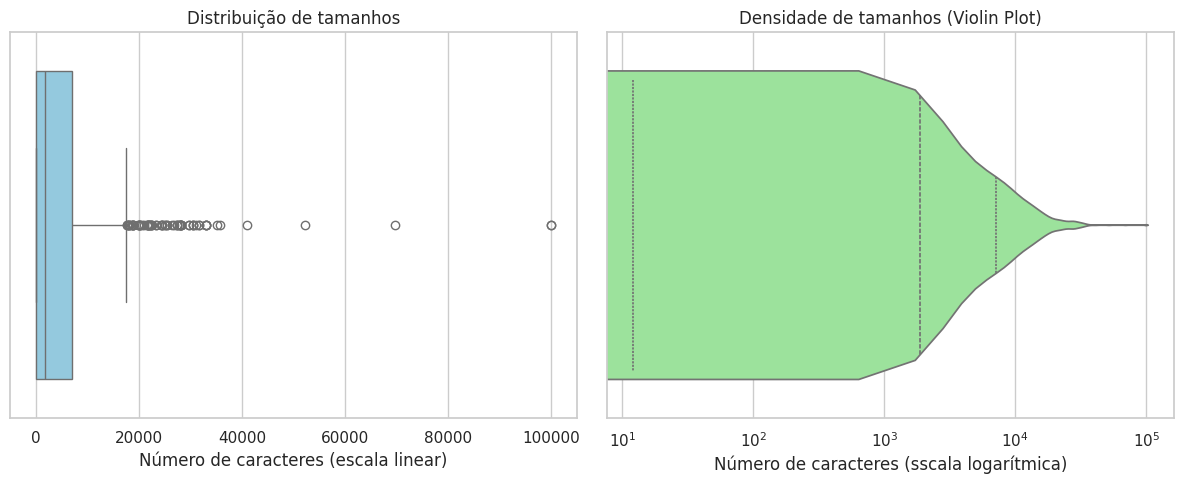

Novo limiar científico definido (P35): Mínimo de 92 caracteres.


In [61]:
# Consolidando todos os tamanhos de arquivos detectados
all_lengths = pd.concat([df_similarity['len1'], df_similarity['len2']])

print(all_lengths.describe())

# Calculando quartis
q1_len = all_lengths.quantile(0.25)
p35 = all_lengths.quantile(0.35)
median_len = all_lengths.median()
q3_len = all_lengths.quantile(0.75)

print(f"--- Estatísticas de Comprimento (Caracteres) ---")
print(f"Q1 (25%): {q1_len:.2f} caracteres")
print(f"P35 (35%): {p35:.2f} caracteres")
print(f"Mediana: {median_len:.2f} caracteres")
print(f"Q3 (75%): {q3_len:.2f} caracteres\n")

# Visualização da Distribuição com Escala Logarítmica
plt.figure(figsize=(12, 5))

# Subplot 1: Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=all_lengths, color='skyblue')
# plt.xscale('log')
plt.title('Distribuição de tamanhos')
plt.xlabel('Número de caracteres (escala linear)')

# Subplot 2: Violin Plot
plt.subplot(1, 2, 2)
sns.violinplot(x=all_lengths, color='lightgreen', inner='quartile')
plt.xscale('log')
plt.title('Densidade de tamanhos (Violin Plot)')
plt.xlabel('Número de caracteres (sscala logarítmica)')

plt.tight_layout()
plt.show()

# Definindo novos limiares baseados nos dados
MIN_CHARS = int(all_lengths.quantile(0.35))
MAX_SIMILARITY = 0.5 # Mantido como teto para busca de divergência
print(f"Novo limiar científico definido (P35): Mínimo de {MIN_CHARS} caracteres.")

Limiar de corte P35: 92.95 caracteres


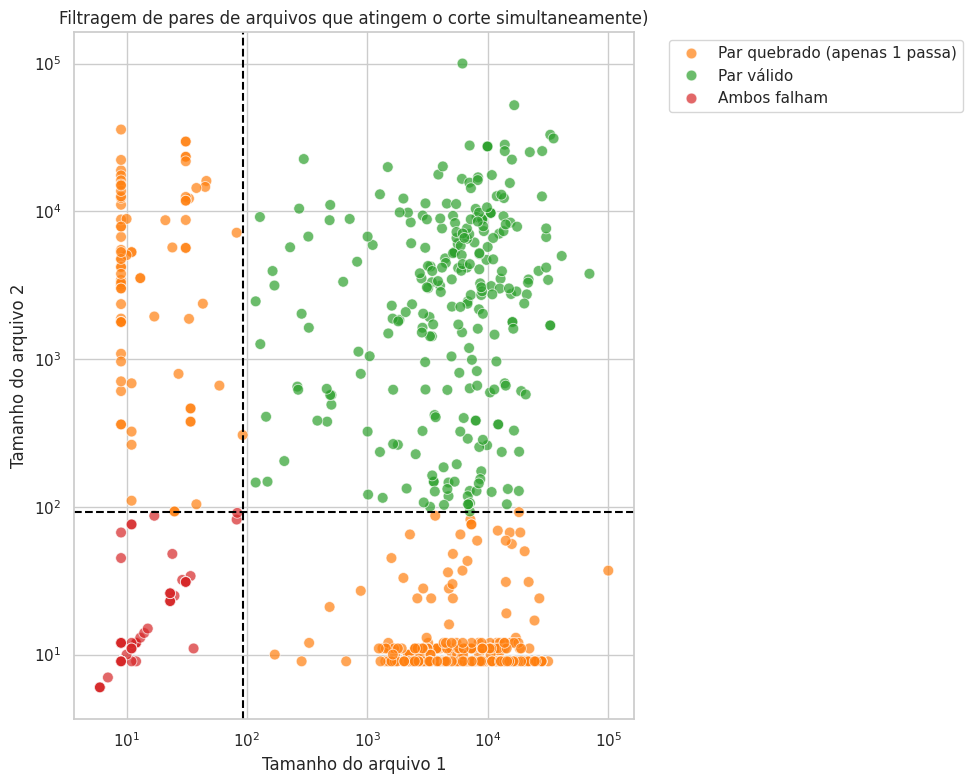

Total de pares originais: 669
Pares que sobreviveram (Válidos): 0


In [62]:
LIMIAR_P35 = all_lengths.quantile(0.35)
print(f"Limiar de corte P35: {LIMIAR_P35:.2f} caracteres")

df_plot = df_similarity.copy()

def classificar_par(row):
    if row['len1'] >= LIMIAR_P35 and row['len2'] >= LIMIAR_P35:
        return 'Par válido'
    elif row['len1'] < LIMIAR_P35 and row['len2'] < LIMIAR_P35:
        return 'Ambos falham'
    else:
        return 'Par quebrado (apenas 1 passa)'

df_plot['Status do Corte'] = df_plot.apply(classificar_par, axis=1)

plt.figure(figsize=(10, 8))
palette = {
    'Par válido': '#2ca02c',
    'Par quebrado (apenas 1 passa)': '#ff7f0e',
    'Ambos falham': '#d62728'
}

ax = sns.scatterplot(
    data=df_plot, 
    x='len1', 
    y='len2', 
    hue='Status do Corte', 
    palette=palette,
    alpha=0.7, 
    s=60
)

plt.xscale('log')
plt.yscale('log')

plt.axvline(LIMIAR_P35, color='black', linestyle='--')
plt.axhline(LIMIAR_P35, color='black', linestyle='--')

plt.title("Filtragem de pares de arquivos que atingem o corte simultaneamente)")
plt.xlabel("Tamanho do arquivo 1")
plt.ylabel("Tamanho do arquivo 2")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

total_bruto = len(df_similarity)
validos = len(df_plot[df_plot['Status do Corte'] == 'Par válido)'])
print(f"Total de pares originais: {total_bruto}")
print(f"Pares que sobreviveram (Válidos): {validos}")

### Filtragem de Conteúdo Relevante

Aplicamos os filtros baseados nos quartis calculados acima.

In [63]:
if not df_similarity.empty:
    df_real_content = df_similarity[(df_similarity['len1'] > 92.95) & (df_similarity['len2'] > 92.95)]
    display(df_real_content.sort_values(by="similarity", ascending=True))
    print(f"{len(df_real_content)} Resultados encontrados.")
else:
    print("Sem dados de similaridade.")

qnt_repo_unicos = df_real_content['repo'].nunique()
print(f"Existem {qnt_repo_unicos} repositório com ao menos um par de arquivos de contexto de IA com semântica textual considerável")


,repo,file1,file2,similarity,len1,len2,words1,words2
271,erxes/erxes,CLAUDE.md,CURSOR,0.000808,32955,1689,3989,249
270,erxes/erxes,AGENTS.md,CURSOR,0.001558,32979,1689,3985,249
453,NVIDIA/cccl,AGENTS.md,CLAUDE.md,0.001667,16468,328,2192,48
463,oxc-project/oxc,AGENTS.md,COPILOT,0.001933,13802,685,1662,103
39,cypress-io/cypress,AGENTS.md,CLAUDE.md,0.002498,11347,1463,1489,233
...,...,...,...,...,...,...,...,...
513,kubeovn/kube-ovn,AGENTS.md,CLAUDE.md,1.000000,2079,2079,309,309
652,jihong88/suneditor,CLAUDE.md,GEMINI.md,1.000000,1490,1490,177,177
112,forem/forem,CURSOR,COPILOT,1.000000,5293,5293,731,731
590,garmeeh/next-seo,AGENTS.md,CLAUDE.md,1.000000,4158,4158,627,627


262 Resultados encontrados.
Existem 205 repositório com ao menos um par de arquivos de contexto de IA com semântica textual considerável


### Definição das Classificações Semânticas

Para garantir a reprodutibilidade e clareza científica, definimos as categorias de análise da seguinte forma:

1. **Redundantes:** Os arquivos apresentam alto grau de sobreposição. As instruções são meras paráfrases ou cópias diretas, indicando que a multiplicidade de arquivos serve apenas para compatibilidade de ferramentas, sem ganho de conteúdo.
2. **Complementares:** Os arquivos compartilham diretrizes globais (ex: stack), mas possuem especializações únicas para a ferramenta alvo (ex: regras de UI específicas para o Cursor vs regras de CLI para o Claude).
3. **Conflitantes:** Existem diretrizes que se contradizem diretamente (ex: padrões de indentação diferentes ou comandos de build distintos), criando ambiguidade para o agente de IA.
4. **Independentes:** Os arquivos tratam de domínios completamente distintos do projeto, com sobreposição próxima de zero.

### Definição das Classificações Semânticas

Para garantir a reprodutibilidade e clareza científica, definimos as categorias de análise da seguinte forma:

1. **Redundantes:** Os arquivos apresentam alto grau de sobreposição (ex: > 70%). As instruções são meras paráfrases ou cópias diretas, indicando que a multiplicidade serve apenas para compatibilidade de ferramentas, sem ganho de conteúdo.
2. **Complementares:** Os arquivos compartilham diretrizes globais (ex: stack), mas possuem especializações únicas para a ferramenta alvo (ex: regras de UI específicas para o Cursor vs regras de CLI para o Claude).
3. **Conflitantes:** Existem diretrizes que se contradizem diretamente (ex: padrões de indentação diferentes ou comandos de build distintos), criando ambiguidade para o agente de IA.
4. **Independentes:** Os arquivos tratam de domínios completamente distintos do projeto, com sobreposição próxima de zero.

## Comparação semântica via LLM

Através do uso do google gemini ou um agente local, será realizada a leitura dos conteúdos dos arquivos e classificação da similaridade semântica dos mesmos.

### Definições gerais

In [22]:
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

In [23]:
client = genai.Client(api_key=GEMINI_API_KEY)

In [66]:
def analisar_semantica(file1_name, file1_content, file2_name, file2_content, provider="gemini"):
    file1_safe = file1_content[:15000]
    file2_safe = file2_content[:15000]
    
    prompt = f"""
            Você é um Pesquisador Especialista em Engenharia de Software e Arquiteto de Sistemas de IA. 
            Sua tarefa é realizar uma Auditoria Semântica Rigorosa entre dois arquivos de instrução de agentes de IA.

            ### ARQUIVOS PARA ANÁLISE
            [Arquivo A: {file1_name}]
            {file1_safe}
            
            [Arquivo B: {file2_name}]
            {file2_safe}

            ### DEFINIÇÕES DE CLASSIFICAÇÃO (CRÍTICO)
            - REDUNDANTES: Os arquivos contêm informações repetidas ou paráfrases. Ambos tentam cumprir o mesmo papel. 
            TESTE: Se você deletar um, o outro ainda contém o conteúdo removido.
            - COMPLEMENTARES: Ambos os arquivos possuem foco no mesmo domínio (ex: arquitetura do sistema), mas um oferece diretrizes gerais e o outro diretrizes especializadas (ex: foco em AWS, foco em segurança). 
            TESTE: Se você deletar um, o outro se torna "incompleto" ou perde uma camada importante de especialização necessária para a ferramenta alvo.
            - CONFLITANTES: Existem diretrizes que se contradizem diretamente (ex: um exige 'npm' e outro 'yarn'; um pede TypeScript e outro JavaScript).
            - INDEPENDENTES: Os arquivos tratam de domínios completamente distintos (ex: um é sobre 'Arquitetura' e o outro é sobre 'Testes' ou 'Documentação'). 
            TESTE: Se você deletar um, o outro continua 100% íntegro, útil e compreensível. O conteúdo de um não ajuda a explicar o conteúdo do outro.

            ### TAREFA
            Analise a relação semântica entre Arquivo A e Arquivo B.
            
            ### FORMATO DE SAÍDA (JSON)
            {{
                "raciocinio_comparativo": "Identifique o domínio de cada arquivo e explique se eles compartilham o mesmo foco ou se são domínios distintos.",
                "sobreposicao_semantica": "[Escolha uma: ALTA, MEDIA, BAIXA, ZERO]",
                "classificacao_final": "[Escolha uma: REDUNDANTES, COMPLEMENTARES, CONFLITANTES, INDEPENDENTES]",
                "justificativa": "Justifique a relação com base nos 'TESTES' definidos acima. Apresente com especificidade os elementos dos arquivos de contexto de IA que justificam a sua classificação final, tenha em mente que estes elementos podem ser procurados manualmente nos arquivos para validar a sua resposta."
            }}
        """
    
    if provider == "gemini":
        if not GEMINI_API_KEY:
            return {"erro": "API key não configurada"}
        try:
            response = client.models.generate_content(
                model='gemini-2.0-flash',
                contents=prompt,
                config=json.loads('{"response_mime_type": "application/json"}'),
            )
            return json.loads(response.text)
        except Exception as e:
            return {"erro": str(e)}
            
    elif provider == "ollama":
        url = "http://localhost:11434/api/generate"
        payload = {
            "model": "qwen2.5:7b",
            "prompt": prompt,
            "format": "json",
            "stream": False,
            "options": {
                "num_ctx": 16384
            }
        }
        try:
            import requests
            response = requests.post(url, json=payload, timeout=120)
            if response.status_code != 200:
                return {"erro": f"Ollama retornou erro {response.status_code}: {response.text}"}
            return json.loads(response.json()["response"])
        except Exception as e:
            return {"erro": f"Falha na conexão com Ollama: {str(e)}"}
    else:
        return {"erro": "Provider não suportado"}


### Via agente externo(gemini)

In [18]:
# resultados_semanticos = []

# if GEMINI_API_KEY and not df_real_content.empty:
#     print(f"Iniciando análise semântica de {len(df_real_content)} pares de arquivos...")
#     for index, row in df_real_content.iterrows():
#         repo = row['repo']
#         f1 = row['file1']
#         f2 = row['file2']
        
#         content1 = fetch_file_content(repo, paths[f1])
#         content2 = fetch_file_content(repo, paths[f2])
        
#         if content1 and content2:
#             res = analisar_semantica(f1, content1, f2, content2, provider="gemini")
#             res['repo'] = repo
#             res['file1'] = f1
#             res['file2'] = f2
#             resultados_semanticos.append(res)
#             print(f"[{repo}] {f1} vs {f2}: {res.get('classificacao_final', 'Erro')} ({int(res.get('metricas', {}).get('overlap_global', 0)*100)}%) - {res.get('justificativa', '...')[:100]}")
#         else:
#             print(f"[{repo}] Falha ao baixar arquivos para comparação.")
            
#     df_semantica = pd.DataFrame(resultados_semanticos)
# else:
#     print("GEMINI_API_KEY não definida ou df_real_content vazio.")


In [ ]:
pd.set_option('display.max_colwidth', None)
if 'df_semantica' in locals() and not df_semantica.empty:
    display(df_semantica)

### Via agente local (Ollama)

Versão utilizada: qwen2.5:7b

In [73]:
resultados_semanticos_local = []

# 1. Cria um recorte com apenas os 50 primeiros pares
df_amostra = df_real_content.head(50)

if not df_amostra.empty:
    # 2. O print agora refletirá o tamanho da amostra (50)
    print(f"Iniciando análise semântica local de {len(df_amostra)} pares de arquivos...")
    
    # 3. Itera sobre a amostra em vez do dataframe original
    for index, row in df_amostra.iterrows():
        repo = row['repo']
        f1 = row['file1']
        f2 = row['file2']
        
        content1 = fetch_file_content(repo, paths[f1])
        content2 = fetch_file_content(repo, paths[f2])
        
        if content1 and content2:
            res = analisar_semantica(f1, content1, f2, content2, provider="ollama")
            res['repo'] = repo
            res['file1'] = f1
            res['file2'] = f2
            resultados_semanticos_local.append(res)
            
            # Nota: O prompt novo não tem mais a chave 'justificativa', 
            # substitua pelo 'raciocinio_comparativo' no print
            print(f"[{repo}] {f1} vs {f2}: {res.get('classificacao_final', 'Erro')} - {res.get('raciocinio_comparativo', '...')[:100]}")
        else:
            print(f"[{repo}] Falha ao baixar arquivos para comparação.")
            
    df_semantica_local = pd.DataFrame(resultados_semanticos_local)

Iniciando análise semântica local de 50 pares de arquivos...
[microsoft/vscode] AGENTS.md vs COPILOT: INDEPENDENTES - Arquivo A se concentra nas instruções gerais para agentes de IA trabalhando com o códigobase do VS C
[microsoft/typescript] AGENTS.md vs COPILOT: Erro - ...
[electron/electron] CLAUDE.md vs COPILOT: Erro - ...


KeyboardInterrupt: 

In [74]:
resultados_semanticos_local = []

if not df_real_content.empty:
    # LIMITANDO PARA ANÁLISE PROVISÓRIA (30 EXEMPLARES)
    df_provisorio = df_real_content.head(30)
    total_analises = len(df_provisorio)
    
    print(f"Iniciando análise PROVISÓRIA de {total_analises} pares de arquivos...")
    for i, (index, row) in enumerate(df_provisorio.iterrows()):
        repo = row['repo']
        f1 = row['file1']
        f2 = row['file2']
        
        content1 = fetch_file_content(repo, paths[f1])
        content2 = fetch_file_content(repo, paths[f2])
        
        if content1 and content2:
            res = analisar_semantica(f1, content1, f2, content2, provider="ollama")
            res['repo'] = repo
            res['file1'] = f1
            res['file2'] = f2
            resultados_semanticos_local.append(res)
            
            overlap_val = res.get('metricas', {}).get('overlap_global', 0)
            try:
                overlap_pct = int(float(overlap_val) * 100)
            except:
                overlap_pct = 0
            
            print(f"[{i+1}/{total_analises}] [{repo}] {f1} vs {f2}: {res.get('classificacao_final', 'Erro')} ({overlap_pct}%) - {res.get('justificativa', '...')[:100]}")
        else:
            print(f"[{i+1}/{total_analises}] [{repo}] Falha ao baixar arquivos.")
            
    df_semantica_local = pd.DataFrame(resultados_semanticos_local)
    print("\nAnálise provisória concluída!")

Iniciando análise PROVISÓRIA de 30 pares de arquivos...
[1/30] [microsoft/vscode] AGENTS.md vs COPILOT: INDEPENDENTES (0%) - Aplicando os testes definidos no formato de saída, podemos concluir que esses arquivos são independe
[2/30] [microsoft/typescript] AGENTS.md vs COPILOT: COMPLEMENTARES (0%) - O conteúdo dos dois arquivos pode ser considerado complementar ao invés de redundante ou conflitante
[3/30] [electron/electron] CLAUDE.md vs COPILOT: COMPLEMENTARES (0%) - Aplicando o 'TESTE' definido, se deletarmos um arquivo, o outro ainda conteria a maioria das informa
[4/30] [gitlabhq/gitlabhq] AGENTS.md vs CLAUDE.md: REDUNDANTES (0%) - Os dois arquivos parecem ser idênticos, compartilhando exatamente o mesmo conteúdo e instruções. Rea
[5/30] [JuliaLang/julia] AGENTS.md vs CLAUDE.md: INDEPENDENTES (0%) - A classificação INDEPENDENTE é a mais apropriada porque se Arquivo B (CLAUDE.md) for removido, o con
[6/30] [pytorch/pytorch] CLAUDE.md vs COPILOT: COMPLEMENTARES (0%) - Baseado nos 'TES

In [76]:
df_semantica_local

,raciocinio_comparativo,sobreposicao_semantica,classificacao_final,justificativa,repo,file1,file2,elementos_do_contexto_de_IA,raciocínio_comparativo
0,"Ambos os arquivos tratam da mesma ferramenta (VS Code) e fornecem instruções relacionadas à utilização do Copilot (agora chamado de AI coding agents). No entanto, o Arquivo A se foca nas instruções gerais para os agentes de IA que trabalham com a base de código do VS Code. Já o Arquivo B fornece detalhes mais específicos sobre a arquitetura interna do VS Code e as diretrizes para testes de TypeScript. Embora ambos estejam relacionados, eles se concentram em aspectos distintos da implementação do Copilot.",BAIXA,INDEPENDENTES,"Aplicando os testes definidos no formato de saída, podemos concluir que esses arquivos são independentes. Se você deletar um, o outro continua 100% íntegro, útil e compreensível. O conteúdo de Arquivo A não ajuda a explicar o conteúdo de Arquivo B e vice-versa. Cada arquivo aborda aspectos diferentes da utilização do Copilot com VS Code: instruções gerais para agentes (Arquivo A) e detalhes sobre a arquitetura interna (Arquivo B). Portanto, eles tratam de domínios distintos, apesar de se relacionarem à mesma ferramenta. Isso justifica a classificação como INDEPENDENTES.",microsoft/vscode,AGENTS.md,COPILOT,NaN,NaN
1,"Ambos os arquivos tratam do mesmo domínio, especificamente as instruções e diretrizes para desenvolvedores de agentes de IA que trabalham no repositório `microsoft/TypeScript`. Ambos contêm informações essenciais sobre o estado atual da reposição, a política de PRs (pull requests) e os procedimentos a seguir para fazer contribuições. No entanto, Arquivo B (`COPILOT`) adiciona uma seção dedicada ao Guia do Copilot, que orienta especificamente como escrever testes de lâmina de quatro (`fourslash tests`) e testes compiladores, além de detalhar as etapas de construção e instruções para esses testes. Arquivo A (`AGENTS.md`), por outro lado, se concentra mais nos procedimentos gerais relacionados à manutenção do repositório e não oferece orientação sobre como escrever testes específicos.",MEDIA,COMPLEMENTARES,"O conteúdo dos dois arquivos pode ser considerado complementar ao invés de redundante ou conflitante. Isso se justifica pela presença de informações distintas e focos diferentes entre os documentos, mas ambos fazem parte do mesmo contexto operacional e direcionam as ações do desenvolvedor em relação à contribuição para o repositório `microsoft/TypeScript`. No caso do Arquivo B (`COPILOT`), ele se destaca com detalhes específicos sobre testes de lâmina de quatro e compilação, enquanto o Arquivo A (`AGENTS.md`) fornece uma visão geral mais ampla da política de PRs e instruções gerais. Se você deletar um desses arquivos, o outro ainda seria suficiente para fornecer uma diretriz geral sobre como contribuir, mas perderia a profundidade específica em testes que é oferecida pelo segundo documento.",microsoft/typescript,AGENTS.md,COPILOT,NaN,NaN
2,"Ambos os arquivos fornecem instruções de desenvolvimento e manutenção do sistema Electron, focando em tarefas de construção, execução, linting, testes e patches. Embora haja diferenças nas denominações exatas das seções e nos detalhes específicos de comandos ou locais de arquivos, a essência da informação fornecida é bastante semelhante.",ALTA,COMPLEMENTARES,"Aplicando o 'TESTE' definido, se deletarmos um arquivo, o outro ainda conteria a maioria das informações necessárias para desenvolver e manter o Electron. No entanto, há certas nuances que um contém e o outro não, o que significa que eles são complementares e cada um oferece uma perspectiva mais especializada sobre diferentes aspectos do Electron Development Guide. Por exemplo, Arquivo A fornece mais detalhes sobre o fluxo de trabalho de patches (como `e patches`), enquanto Arquivo B inclui instruções específicas para rodar testes isolados usando Node.js (`node script/node-spec-runner.js`). Essas diferenças não são tão profundas a ponto de tornarem as i

In [69]:
try:
    # Caminho preferencial na pasta de dados
    output_dir_data = "../../../data/content_analysis"
    os.makedirs(output_dir_data, exist_ok=True)
    output_path_data = os.path.join(output_dir_data, "semantic_analysis_rq01_21.csv")
    
    df_semantica_local.to_csv(output_path_data, index=False)
    print(f"\n[OK] Salvo em data: {os.path.abspath(output_path_data)}")
    
    # Backup na pasta atual
    output_path_local = "semantic_analysis_rq01.csv"
    df_semantica_local.to_csv(output_path_local, index=False)
    print(f"[OK] Salvo na pasta atual: {os.path.abspath(output_path_local)}")
except Exception as e:
    print(f"\n[ERRO] Falha ao salvar: {e}")
    print(f"Diretório de trabalho: {os.getcwd()}")


[ERRO] Falha ao salvar: name 'df_semantica_local' is not defined
Diretório de trabalho: /home/keven/Documents/tcc/repo-pesquisa/notebooks/research_questions/rq01


In [ ]:
df_semantica_local[['repo', ['']]]

In [77]:
pd.set_option('display.max_colwidth', None)
display(df_semantica_local)

,raciocinio_comparativo,sobreposicao_semantica,classificacao_final,justificativa,repo,file1,file2,elementos_do_contexto_de_IA,raciocínio_comparativo
0,"Ambos os arquivos tratam da mesma ferramenta (VS Code) e fornecem instruções relacionadas à utilização do Copilot (agora chamado de AI coding agents). No entanto, o Arquivo A se foca nas instruções gerais para os agentes de IA que trabalham com a base de código do VS Code. Já o Arquivo B fornece detalhes mais específicos sobre a arquitetura interna do VS Code e as diretrizes para testes de TypeScript. Embora ambos estejam relacionados, eles se concentram em aspectos distintos da implementação do Copilot.",BAIXA,INDEPENDENTES,"Aplicando os testes definidos no formato de saída, podemos concluir que esses arquivos são independentes. Se você deletar um, o outro continua 100% íntegro, útil e compreensível. O conteúdo de Arquivo A não ajuda a explicar o conteúdo de Arquivo B e vice-versa. Cada arquivo aborda aspectos diferentes da utilização do Copilot com VS Code: instruções gerais para agentes (Arquivo A) e detalhes sobre a arquitetura interna (Arquivo B). Portanto, eles tratam de domínios distintos, apesar de se relacionarem à mesma ferramenta. Isso justifica a classificação como INDEPENDENTES.",microsoft/vscode,AGENTS.md,COPILOT,NaN,NaN
1,"Ambos os arquivos tratam do mesmo domínio, especificamente as instruções e diretrizes para desenvolvedores de agentes de IA que trabalham no repositório `microsoft/TypeScript`. Ambos contêm informações essenciais sobre o estado atual da reposição, a política de PRs (pull requests) e os procedimentos a seguir para fazer contribuições. No entanto, Arquivo B (`COPILOT`) adiciona uma seção dedicada ao Guia do Copilot, que orienta especificamente como escrever testes de lâmina de quatro (`fourslash tests`) e testes compiladores, além de detalhar as etapas de construção e instruções para esses testes. Arquivo A (`AGENTS.md`), por outro lado, se concentra mais nos procedimentos gerais relacionados à manutenção do repositório e não oferece orientação sobre como escrever testes específicos.",MEDIA,COMPLEMENTARES,"O conteúdo dos dois arquivos pode ser considerado complementar ao invés de redundante ou conflitante. Isso se justifica pela presença de informações distintas e focos diferentes entre os documentos, mas ambos fazem parte do mesmo contexto operacional e direcionam as ações do desenvolvedor em relação à contribuição para o repositório `microsoft/TypeScript`. No caso do Arquivo B (`COPILOT`), ele se destaca com detalhes específicos sobre testes de lâmina de quatro e compilação, enquanto o Arquivo A (`AGENTS.md`) fornece uma visão geral mais ampla da política de PRs e instruções gerais. Se você deletar um desses arquivos, o outro ainda seria suficiente para fornecer uma diretriz geral sobre como contribuir, mas perderia a profundidade específica em testes que é oferecida pelo segundo documento.",microsoft/typescript,AGENTS.md,COPILOT,NaN,NaN
2,"Ambos os arquivos fornecem instruções de desenvolvimento e manutenção do sistema Electron, focando em tarefas de construção, execução, linting, testes e patches. Embora haja diferenças nas denominações exatas das seções e nos detalhes específicos de comandos ou locais de arquivos, a essência da informação fornecida é bastante semelhante.",ALTA,COMPLEMENTARES,"Aplicando o 'TESTE' definido, se deletarmos um arquivo, o outro ainda conteria a maioria das informações necessárias para desenvolver e manter o Electron. No entanto, há certas nuances que um contém e o outro não, o que significa que eles são complementares e cada um oferece uma perspectiva mais especializada sobre diferentes aspectos do Electron Development Guide. Por exemplo, Arquivo A fornece mais detalhes sobre o fluxo de trabalho de patches (como `e patches`), enquanto Arquivo B inclui instruções específicas para rodar testes isolados usando Node.js (`node script/node-spec-runner.js`). Essas diferenças não são tão profundas a ponto de tornarem as i

## Análise Estatística e Visualização (H1)

Nesta seção, validamos a **Hipótese 1** analisando a distribuição das métricas de sobreposição e conflito.

In [78]:
import numpy as np
def extrair_metrica(col, chave):
    try:
        if isinstance(col, str): col = json.loads(col.replace("'", "\""))
        return col.get(chave, 0)
    except: return 0

df_plot = df_semantica_local.copy() if 'df_semantica_local' in locals() else pd.DataFrame()
if not df_plot.empty:
    if 'metricas' in df_plot.columns:
        df_plot['overlap'] = df_plot['metricas'].apply(lambda x: extrair_metrica(x, 'overlap_global'))
        label_col = 'classificacao_final'
    else:
        df_plot['overlap'] = df_plot['similaridade_semantica'] / 100
        label_col = 'classificacao'
    
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x=label_col, y='overlap', palette='Set2')
    plt.title('Distribuição de Overlap Semântico por Categoria (H1)')
    plt.show()

KeyError: 'similaridade_semantica'

## Visualização dos Resultados (Hipótese 1)

Nesta seção, apresentamos a distribuição das classificações semânticas e a dispersão do overlap global para validar a redundância ou especialização dos arquivos.

/tmp/ipykernel_991423/3257883299.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x=label_col, y='overlap_num', palette='viridis', ax=ax2)


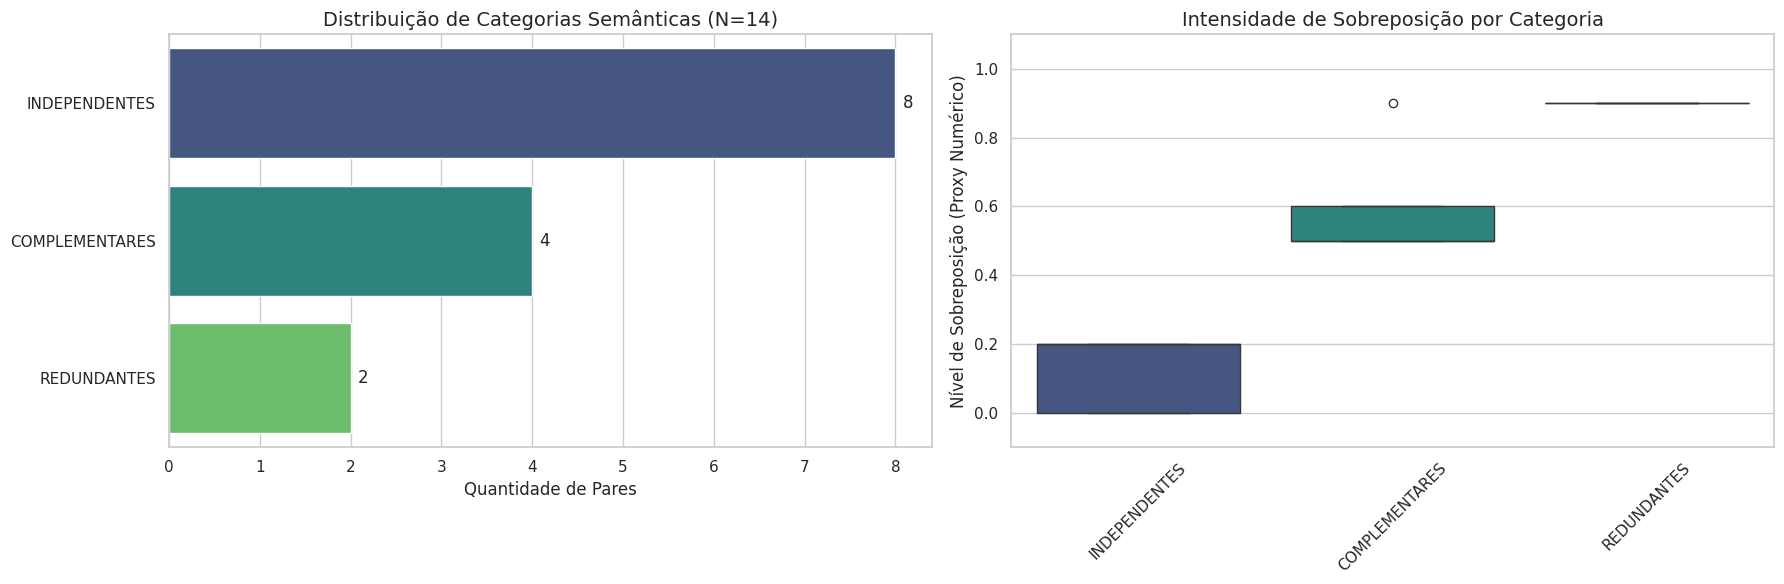

sobreposicao_cat,ALTA,BAIXA,MEDIA,ZERO
classificacao_final,,,,
COMPLEMENTARES,1,0,3,0
INDEPENDENTES,0,5,0,3
REDUNDANTES,2,0,0,0


In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_semantica_local' in locals() and not df_semantica_local.empty:
    df_final = df_semantica_local.copy()
    
    # Mapeamento de Sobreposição Semântica (Categorical -> Numeric para Boxplot)
    mapping_overlap = {
        'ALTA': 0.9,
        'MEDIA': 0.5,
        'BAIXA': 0.2,
        'ZERO': 0.0
    }
    
    # Limpeza e Normalização dos Dados
    def normalize_str(val): return str(val).strip().upper() if val else ""
    
    label_col = 'classificacao_final'
    overlap_col = 'sobreposicao_semantica'
    
    df_final[label_col] = df_final[label_col].apply(normalize_str)
    df_final['sobreposicao_cat'] = df_final[overlap_col].apply(normalize_str)
    
    # Converte para numérico usando o mapa
    df_final['overlap_num'] = df_final['sobreposicao_cat'].map(mapping_overlap).fillna(0)

    class_counts = df_final[label_col].value_counts()

    # Layout da Figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # 1. Gráfico de Barras (Frequência de Categorias)
    sns.barplot(y=class_counts.index, x=class_counts.values, hue=class_counts.index, palette='viridis', ax=ax1, legend=False)
    ax1.set_title('Distribuição de Categorias Semânticas (N=14)', fontsize=14)
    ax1.set_xlabel('Quantidade de Pares')
    ax1.set_ylabel('')
    for p in ax1.patches:
        ax1.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height()/2.), ha='left', va='center', xytext=(5, 0), textcoords='offset points')

    # 2. Boxplot (Intensidade da Sobreposição)
    sns.boxplot(data=df_final, x=label_col, y='overlap_num', palette='viridis', ax=ax2)
    ax2.set_title('Intensidade de Sobreposição por Categoria', fontsize=14)
    ax2.set_ylabel('Nível de Sobreposição (Proxy Numérico)')
    ax2.set_xlabel('')
    ax2.set_ylim(-0.1, 1.1)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
    
    # Resumo Estatístico

### Tabela de Contingência (Frequência por Intensidade):')
    contingencia = pd.crosstab(df_final[label_col], df_final['sobreposicao_cat'])
    from IPython.display import display
    display(contingencia)
else:
    print('Execute a análise semântica local com o novo prompt primeiro.')

In [ ]:
display(df_plot.query('classificacao == "Redundantes"')[['repo', 'file1', 'file2', 'justificativa_final', 'detalhes_criticos']])


,repo,file1,file2,justificativa_final,detalhes_criticos
2,electron/electron,CLAUDE.md,COPILOT,"Os dois arquivos apresentam uma grande semelhança em termos de regras e instruções, mas o Arquivo B oferece um workflow único que pode ser mantido separadamente para melhorar a eficiência.","{'redundancias': ['Comandos de sincronização repetidos'], 'conflitos': [], 'valor_agregado': 'O Arquivo B foca em um workflow específico e os comandos repetidos podem ser otimizados ou eliminados sem comprometer a funcionalidade.'}"
4,metabase/metabase,CLAUDE.md,COPILOT,"A análise revelou que os dois arquivos têm regras semelhantes, mas com diferentes focos. Embora haja algumas redundâncias, a especialização dos arquivos pode ser útil para desenvolvedores com objetivos específicos.","{'redundancias': ['documentação de código, regras de segurança e performance'], 'conflitos': [], 'valor_agregado': 'Os arquivos têm objetivos diferentes e podem gerar confusão se mantidos juntos.'}"
10,denoland/deno,CLAUDE.md,COPILOT,"A análise dos arquivos revelou uma forte redundância na execução de tarefas relacionadas a build e configuração, destacando a necessidade de manter os dois arquivos separados para evitar conflitos desnecessários.","{'redundancias': ['Repetição de instruções relacionadas a build e configuração'], 'conflitos': [], 'valor_agregado': 'O arquivo B pode ser considerado um complemento do A, pois oferece opções adicionais para o desenvolvedor'}"
11,remix-run/react-router,AGENTS.md,CLAUDE.md,"Os dois arquivos compartilham muitas semelhanças, mas a redundância de instruções e comandos sugere que podem ser unificados ou reestruturados para melhorar a eficiência.","{'redundancias': ['Uso de comandos semelhantes em ambos os arquivos', 'Repetição de instruções de teste'], 'conflitos': [], 'valor_agregado': 'Embora haja algumas redundâncias, é recomendável manter o Arquivo A focando em um workflow específico enquanto o B foca em outro.'}"
13,apereo/cas,AGENTS.md,COPILOT,"Os dois arquivos têm instruções técnicas repetidas e não apresentam conflitos significativos, tornando um dos arquivos desnecessário.","{'redundancias': ['repetição de instruções relacionadas a módulos de suporte'], 'conflitos': [], 'valor_agregado': 'A existência de múltiplos arquivos agrega valor real, mas geram sobrecarga cognitiva.'}"
20,mochajs/mocha,AGENTS.md,COPILOT,"Apesar da grande semelhança entre os arquivos, a redundância de instruções e scripts torna inviável manter ambos arquivos separados.","{'redundancias': ['Instruções de deploy, scripts e testes repetidos'], 'conflitos': [], 'valor_agregado': 'Os dois arquivos apresentam instruções muito semelhantes, tornando desnecessário manter ambos separados.'}"
24,swc-project/swc,AGENTS.md,CLAUDE.md,"O Arquivo B tem instruções repetidas do Arquivo A e algumas instruções que podem ser úteis, mas geram possibilidade de confusão. É recomendável manter os dois arquivos com algumas redundâncias, mas mantendo a integridade dos passos gerais de trabalho.","{'redundancias': ['Todas as instruções relacionadas a estruturas de diretórios e commitar os módulos do projeto.', 'A instrução 'use gh' é repetida sem necessidade.'], 'conflitos': ['Nenhuma instrução se contradiz, mas há redundância nas instruções relacionadas a estrutura dos diretórios e uso de git.'], 'valor_agregado': 'Se os dois arquivos forem mantidos juntos, pode gerar confusão para quem não está familiarizado com o projeto. A recomendação é manter um arquivo focado nos passos gerais de trabalho do repositório.'}"
29,Floorp-Projects/Floorp,CURSOR,COPILOT,"Os dois arquivos tendem a ter muitas repetições de regras, mas também há espaço para algumas configurações únicas.","{'redundancias': ['ações de regra repetidas em ambos os arquivos'], 'conflitos': [], 'valor_agregado': 'Ambos os arquivos têm muito que se repetir, mas há um valor especializado na configuração do Floorp'}"
31,bigbluebutton/bigbluebutton,AGENTS.md,CLAUDE.md,"Os arquivos têm uma grande semelhança nas instruções 